# Question 3: Deep Learning for Default Prediction

**IB98D0: Advanced Data Analytics — Group Assignment 2025-26**

This notebook implements:
- Q3a: Prediction task definition and train/validation/test split
- Q3b: Logistic Regression, Basic DNN, and Optimised DNN in PyTorch
- Q3c: Model evaluation by borrower cluster

**Cluster Definitions (from Q2):
- Cluster 0 – High-Leverage Segment: High income, high DTI, many open accounts
- Cluster 1 – Prior Default Segment: High historical delinquency (delinq_2yrs ≈ 1.29)
- Cluster 2 – Conservative Segment: Lowest income, very low DTI, near-zero defaults


In [3]:
pip install torch

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.8.0


In [5]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

## Q3a. Prediction Task and Data Preparation

In [ ]:
#Load Dataset
df = pd.read_csv('early_2012_2013_loan_sample_with_outcome.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution (loan_is_bad):')
print(df['loan_is_bad'].value_counts())
print(f'Default rate: {df["loan_is_bad"].mean():.2%}')

Dataset shape: (50000, 57)

Class distribution (loan_is_bad):
loan_is_bad
False    42186
True      7814
Name: count, dtype: int64
Default rate: 15.63%


In [ ]:
#Feature Engineering: select only features that available at origination time only in order to reflects the real scenario and prevent data leakage.

FEATURES = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'emp_length', 'grade', 'home_ownership',
    'verification_status', 'purpose'
]
TARGET = 'loan_is_bad'

df_model = df[FEATURES + [TARGET]].copy()

# Clean revol_util: strip % and convert to float
df_model['revol_util'] = (
    df_model['revol_util']
    .astype(str)
    .str.replace('%', '', regex=False)
    .replace('nan', np.nan)
    .astype(float)
)

#Encode grade as ordinal (A=1 ... G=7)
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df_model['grade'] = df_model['grade'].map(grade_map).fillna(4)

#One-hot encode categorical features
cat_cols = ['home_ownership', 'verification_status', 'purpose']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

#Drop remaining NaNs
df_model.dropna(inplace=True)

print(f'Feature matrix shape after preprocessing: {df_model.shape}')
print(f'Number of features (including revol_util): {df_model.shape[1] - 1}')
print(f'revol_util sample values: {df_model["revol_util"].describe().round(2).to_dict()}')


Feature matrix shape after preprocessing: (48168, 34)
Number of features (including revol_util): 33
revol_util sample values: {'count': 48168.0, 'mean': 58.95, 'std': 23.32, 'min': 0.0, '25%': 43.2, '50%': 61.6, '75%': 77.5, 'max': 113.9}


In [ ]:
#Clustering using all 7 Q2 features — nearest-centroid voting
#
# K-means cluster centres (unscaled, from Q2 output):
#
#   Feature           C0-High-Leverage   C1-Prior-Default   C2-Conservative
#   dti                   20.6               17.1               15.4
#   revol_util            58.1               58.6               59.6   (not in df_model — skipped)
#   annual_inc          82,100             77,411             58,506
#   inq_last_6mths         1.11               0.839              0.626
#   delinq_2yrs            0.019              1.29               0.007
#   open_acc              14.9               11.2                8.30
#   total_acc             33.6               27.1               17.0
#
# Method: each feature votes for the cluster whose centre is closest.
# delinq_2yrs gets double weight — it is the strongest discriminator
# (centre gap: 1.29 vs 0.019, a ~68x difference).
# revol_util is excluded as it is not in df_model (not in FEATURES list).

# K-means cluster centres from Q2
CENTRES = {
    0: {'dti': 20.6,  'annual_inc': 82100,  'inq_last_6mths': 1.110,
        'delinq_2yrs': 0.019, 'open_acc': 14.9, 'total_acc': 33.6},  # High-Leverage
    1: {'dti': 17.1,  'annual_inc': 77411,  'inq_last_6mths': 0.839,
        'delinq_2yrs': 1.290, 'open_acc': 11.2, 'total_acc': 27.1},  # Prior Default
    2: {'dti': 15.4,  'annual_inc': 58506,  'inq_last_6mths': 0.626,
        'delinq_2yrs': 0.007, 'open_acc':  8.30, 'total_acc': 17.0},  # Conservative
}

# delinq_2yrs votes twice — strongest signal separating Prior Default from the rest
WEIGHTS = {
    'dti': 1, 'annual_inc': 1, 'inq_last_6mths': 1,
    'delinq_2yrs': 2, 'open_acc': 1, 'total_acc': 1
}

def assign_cluster(row):
    """
    Nearest-centroid assignment using 6 of the 7 Q2 clustering features
    (revol_util excluded — not in df_model).
    Each feature casts weighted votes for its closest cluster centre.
    """
    votes = {0: 0, 1: 0, 2: 0}
    for feat, weight in WEIGHTS.items():
        if feat not in row.index or pd.isna(row[feat]):
            continue
        closest = min(CENTRES.keys(), key=lambda c: abs(row[feat] - CENTRES[c][feat]))
        votes[closest] += weight
    return max(votes, key=votes.get)

df_model['cluster'] = df_model.apply(assign_cluster, axis=1)

cluster_names = {
    0: 'High-Leverage',
    1: 'Prior Default',
    2: 'Conservative'
}

print('K-means centres used (from Q2):')
print('  C0 High-Leverage : dti=20.6, delinq=0.019, inc=82,100, inq=1.11,  open=14.9, total=33.6')
print('  C1 Prior Default : dti=17.1, delinq=1.290, inc=77,411, inq=0.839, open=11.2, total=27.1')
print('  C2 Conservative  : dti=15.4, delinq=0.007, inc=58,506, inq=0.626, open=8.30, total=17.0')
print()
print('Cluster distribution (Q2 reference: C0=16,877  C1=6,454  C2=25,679):')
for c, name in cluster_names.items():
    n = (df_model['cluster'] == c).sum()
    rate = df_model.loc[df_model['cluster'] == c, TARGET].mean()
    print(f'  Cluster {c} ({name}): n={n:,}, default rate={rate:.2%}')


K-means centres used (from Q2):
  C0 High-Leverage : dti=20.6, delinq=0.019, inc=82,100, inq=1.11,  open=14.9, total=33.6
  C1 Prior Default : dti=17.1, delinq=1.290, inc=77,411, inq=0.839, open=11.2, total=27.1
  C2 Conservative  : dti=15.4, delinq=0.007, inc=58,506, inq=0.626, open=8.30, total=17.0

Cluster distribution (Q2 reference: C0=16,877  C1=6,454  C2=25,679):
  Cluster 0 (High-Leverage): n=10,004, default rate=16.71%
  Cluster 1 (Prior Default): n=4,372, default rate=15.67%
  Cluster 2 (Conservative): n=33,792, default rate=15.11%


In [ ]:
#Train 70% / Validation 15% / Test Split 15% using stratified sampling

feature_cols = [c for c in df_model.columns if c not in [TARGET, 'cluster']]
X = df_model[feature_cols].values
y = df_model[TARGET].astype(int).values
clusters = df_model['cluster'].values

#Step 1: Split out 15% test
X_temp, X_test, y_temp, y_test, cl_temp, cl_test = train_test_split(
    X, y, clusters, test_size=0.15, random_state=42, stratify=y
)

#Step 2: Split remaining into 70% train and 15% val (0.15/0.85 ≈ 0.1765)
X_train_raw, X_val, y_train_raw, y_val, cl_train, cl_val = train_test_split(
    X_temp, y_temp, cl_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f'Train size (before resampling): {len(X_train_raw):,}')
print(f'Validation size: {len(X_val):,}')
print(f'Test size: {len(X_test):,}')
print(f'\nTrain class distribution: {np.bincount(y_train_raw)}')

Train size (before resampling): 33,715
Validation size: 7,227
Test size: 7,226

Train class distribution: [28491  5224]


In [ ]:
#Undersampling on the training set to address class imbalance because the dataset is large

train_df = pd.DataFrame(X_train_raw, columns=feature_cols)
train_df['label'] = y_train_raw

majority = train_df[train_df['label'] == 0]
minority = train_df[train_df['label'] == 1]

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42)
X_train = train_balanced[feature_cols].values
y_train = train_balanced['label'].values

print(f'Balanced train size: {len(X_train):,}')
print(f'Class distribution after undersampling: {np.bincount(y_train)}')

Balanced train size: 10,448
Class distribution after undersampling: [5224 5224]


In [ ]:
#Scaling(fit on train, transform val/test)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

#Convert to PyTorch tensors
def to_tensors(X, y):
    return (torch.FloatTensor(X),
            torch.FloatTensor(y).unsqueeze(1))

X_tr_t, y_tr_t = to_tensors(X_train_sc, y_train)
X_vl_t, y_vl_t = to_tensors(X_val_sc, y_val)
X_te_t, y_te_t = to_tensors(X_test_sc, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train_sc.shape[1]
print(f'Input dimension: {INPUT_DIM}')
print(f"Training samples: {len(X_train_sc)}, Validation samples: {len(X_val_sc)}, Test samples: {len(X_test_sc)}")

Input dimension: 33
Training samples: 10448, Validation samples: 7227, Test samples: 7226


## Q3b. Model Design and Training

We train three progressively more sophisticated models:
1. **Logistic Regression** – linear baseline
2. **Basic DNN** – two hidden layers, ReLU, Adam
3. **Optimised DNN** – BatchNorm, Dropout, AdamW, LR scheduler, early stopping

In [ ]:
#Shared Evaluation Helper
def evaluate_model(model, loader, threshold=0.5):
    """Returns dict of metrics for a binary classifier."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            probs = model(X_b).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy().flatten())
    probs  = np.array(all_probs)
    labels = np.array(all_labels).astype(int)
    preds  = (probs >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'auc':      roc_auc_score(labels, probs),
        'probs':    probs,
        'labels':   labels,
        'preds':    preds
    }

def evaluate_on_raw(model, X_sc, y_raw, threshold=0.5):
    """Evaluate on numpy arrays (used for cluster-level evaluation)."""
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_sc).to(device)
        probs = model(X_t).cpu().numpy().flatten()
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_raw, preds),
        'auc':      roc_auc_score(y_raw, probs) if len(np.unique(y_raw)) > 1 else np.nan,
        'probs':    probs,
        'preds':    preds
    }

### Model 1: Logistic Regression

In [ ]:
class LogisticRegressionModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

lr_model = LogisticRegressionModel(INPUT_DIM).to(device)
print(lr_model)

LogisticRegressionModel(
  (linear): Linear(in_features=33, out_features=1, bias=True)
)


In [ ]:
#Train Logistic Regression

#Define loss and optimizer
criterion_lr = nn.BCELoss()
optimizer_lr = optim.SGD(lr_model.parameters(), lr=0.01)

EPOCHS_LR = 100
lr_train_losses, lr_val_losses = [], []

for epoch in range(EPOCHS_LR):
    lr_model.train()
    epoch_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_lr.zero_grad()
        out = lr_model(X_b)
        loss = criterion_lr(out, y_b)
        loss.backward()
        optimizer_lr.step()
        epoch_loss += loss.item() * X_b.size(0)
    lr_train_losses.append(epoch_loss / len(train_loader.dataset))

    #Validation loss
    lr_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = lr_model(X_b)
            val_loss += criterion_lr(out, y_b).item() * X_b.size(0)
    lr_val_losses.append(val_loss / len(val_loader.dataset))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_LR}]  '
              f'Train Loss: {lr_train_losses[-1]:.4f}  '
              f'Val Loss: {lr_val_losses[-1]:.4f}')

print('\nLogistic Regression training complete.')

Epoch [20/100]  Train Loss: 0.6489  Val Loss: 0.6481
Epoch [40/100]  Train Loss: 0.6488  Val Loss: 0.6495
Epoch [60/100]  Train Loss: 0.6488  Val Loss: 0.6488
Epoch [80/100]  Train Loss: 0.6487  Val Loss: 0.6484
Epoch [100/100]  Train Loss: 0.6488  Val Loss: 0.6483

Logistic Regression training complete.


### Model 2: Basic DNN

In [ ]:
class BasicDNN(nn.Module):
    """Two-hidden-layer feedforward network for binary classification."""
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

dnn_model = BasicDNN(INPUT_DIM).to(device)
print(dnn_model)

BasicDNN(
  (layers): Sequential(
    (0): Linear(in_features=33, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
#Train Basic DNN
criterion_dnn = nn.BCELoss()
optimizer_dnn = optim.Adam(dnn_model.parameters(), lr=0.001)

EPOCHS_DNN = 100
dnn_train_losses, dnn_val_losses = [], []

for epoch in range(EPOCHS_DNN):
    dnn_model.train()
    epoch_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_dnn.zero_grad()
        out = dnn_model(X_b)
        loss = criterion_dnn(out, y_b)
        loss.backward()
        optimizer_dnn.step()
        epoch_loss += loss.item() * X_b.size(0)
    dnn_train_losses.append(epoch_loss / len(train_loader.dataset))

    dnn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            val_loss += criterion_dnn(dnn_model(X_b), y_b).item() * X_b.size(0)
    dnn_val_losses.append(val_loss / len(val_loader.dataset))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_DNN}]  '
              f'Train Loss: {dnn_train_losses[-1]:.4f}  '
              f'Val Loss: {dnn_val_losses[-1]:.4f}')

print('\nBasic DNN training complete.')

Epoch [20/100]  Train Loss: 0.6099  Val Loss: 0.6438
Epoch [40/100]  Train Loss: 0.5672  Val Loss: 0.6513
Epoch [60/100]  Train Loss: 0.5287  Val Loss: 0.8183
Epoch [80/100]  Train Loss: 0.4953  Val Loss: 0.8511
Epoch [100/100]  Train Loss: 0.4706  Val Loss: 0.8993

Basic DNN training complete.


### Model 3: Optimised DNN

In [ ]:
class OptimisedDNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.15):
        super().__init__()
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Output
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

opt_model = OptimisedDNN(INPUT_DIM, dropout_rate=0.15).to(device)
print(opt_model)


OptimisedDNN(
  (network): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


In [ ]:
#Train Optimised DNN
criterion_opt = nn.BCELoss()
optimizer_opt = optim.AdamW(opt_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_opt = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_opt, mode='min', factor=0.5, patience=5
)

EPOCHS_OPT = 150
PATIENCE    = 15
best_val_loss   = float('inf')
epochs_no_improve = 0

opt_train_losses, opt_val_losses = [], []

for epoch in range(EPOCHS_OPT):
    # Training
    opt_model.train()
    epoch_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)

        optimizer_opt.zero_grad()
        out = opt_model(X_b)
        loss = criterion_opt(out, y_b)
        loss.backward()
        optimizer_opt.step()

        epoch_loss += loss.item() * X_b.size(0)

    train_l = epoch_loss / len(train_loader.dataset)
    opt_train_losses.append(train_l)

    # Validation
    opt_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            val_loss += criterion_opt(opt_model(X_b), y_b).item() * X_b.size(0)
    val_l = val_loss / len(val_loader.dataset)
    opt_val_losses.append(val_l)

    scheduler_opt.step(val_l)

    # Early stopping
    if val_l < best_val_loss:
        best_val_loss = val_l
        epochs_no_improve = 0
        torch.save(opt_model.state_dict(), 'best_opt_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_OPT}]  '
              f'Train Loss: {train_l:.4f}  '
              f'Val Loss: {val_l:.4f}')

# Reload best weights
opt_model.load_state_dict(torch.load('best_opt_model.pth'))
print('\nOptimised DNN training complete.')


Epoch [20/150]  Train Loss: 0.6261  Val Loss: 0.6395
Early stopping at epoch 36

Optimised DNN training complete.


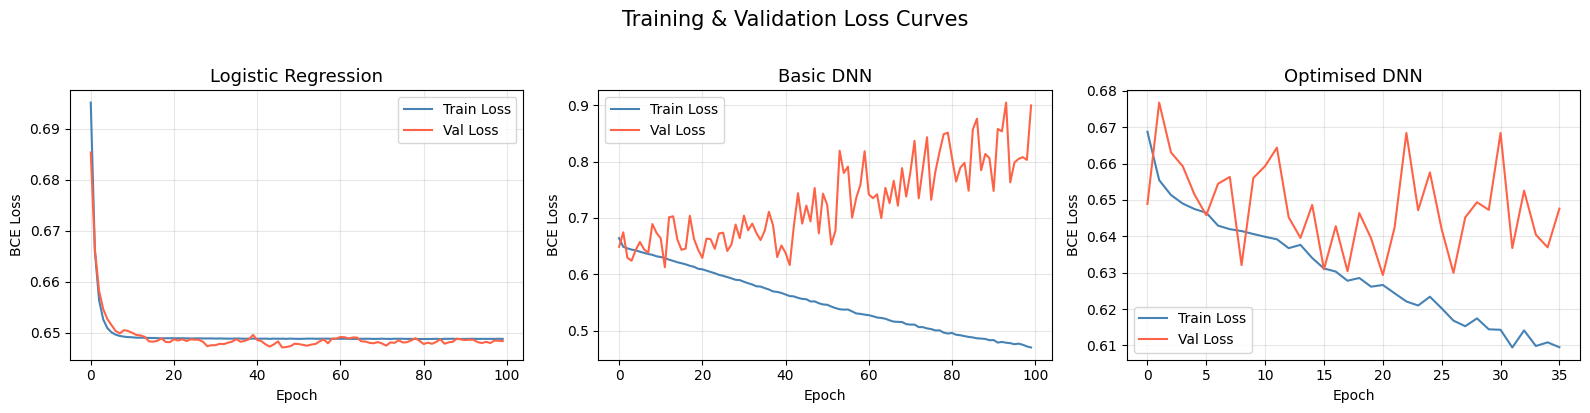

In [ ]:
#Plot Learning Curves for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, train_l, val_l, title in zip(
    axes,
    [lr_train_losses, dnn_train_losses, opt_train_losses],
    [lr_val_losses,   dnn_val_losses,   opt_val_losses],
    ['Logistic Regression', 'Basic DNN', 'Optimised DNN']
):
    ax.plot(train_l, label='Train Loss', color='steelblue')
    ax.plot(val_l,   label='Val Loss',   color='tomato')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Q3c. Model Evaluation

##Overall Performance Metrics

In [ ]:
#Overall Performance Metrics
models = {
    'Logistic Regression': lr_model,
    'Basic DNN':           dnn_model,
    'Optimised DNN':       opt_model
}

results_overall = {}
for name, model in models.items():
    res = evaluate_model(model, test_loader)
    results_overall[name] = res
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Accuracy: {res["accuracy"]:.4f}')
    print(f'  ROC-AUC:  {res["auc"]:.4f}')
    print()
    print(classification_report(res['labels'], res['preds'],
                                target_names=['Not Default', 'Default']))


  Logistic Regression
  Accuracy: 0.6266
  ROC-AUC:  0.6912

              precision    recall  f1-score   support

 Not Default       0.91      0.62      0.74      6106
     Default       0.24      0.66      0.35      1120

    accuracy                           0.63      7226
   macro avg       0.57      0.64      0.55      7226
weighted avg       0.80      0.63      0.68      7226


  Basic DNN
  Accuracy: 0.5489
  ROC-AUC:  0.6311

              precision    recall  f1-score   support

 Not Default       0.89      0.53      0.66      6106
     Default       0.20      0.66      0.31      1120

    accuracy                           0.55      7226
   macro avg       0.55      0.59      0.49      7226
weighted avg       0.79      0.55      0.61      7226


  Optimised DNN
  Accuracy: 0.6405
  ROC-AUC:  0.6849

              precision    recall  f1-score   support

 Not Default       0.90      0.65      0.75      6106
     Default       0.24      0.62      0.35      1120

    accuracy

In [ ]:
#Summary Comparison Table
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, res in results_overall.items():
    rows.append({
        'Model': name,
        'Accuracy': f'{res["accuracy"]:.4f}',
        'ROC-AUC':  f'{res["auc"]:.4f}',
        'Precision': f'{precision_score(res["labels"], res["preds"]):.4f}',
        'Recall':    f'{recall_score(res["labels"], res["preds"]):.4f}',
        'F1':        f'{f1_score(res["labels"], res["preds"]):.4f}',
    })

summary_df = pd.DataFrame(rows)
print('Overall Test Set Performance:')
print(summary_df.to_string(index=False))

Overall Test Set Performance:
              Model Accuracy ROC-AUC Precision Recall     F1
Logistic Regression   0.6266  0.6912    0.2415 0.6580 0.3533
          Basic DNN   0.5489  0.6311    0.2034 0.6554 0.3105
      Optimised DNN   0.6405  0.6849    0.2412 0.6152 0.3466


## Confusion Metrices

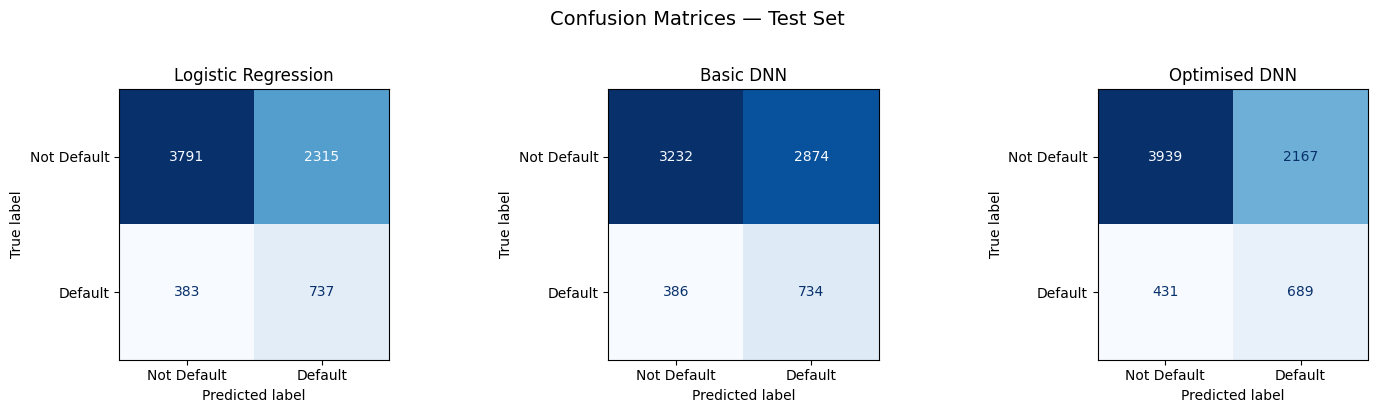

In [ ]:
#Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results_overall.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Default', 'Default']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ROC Curves

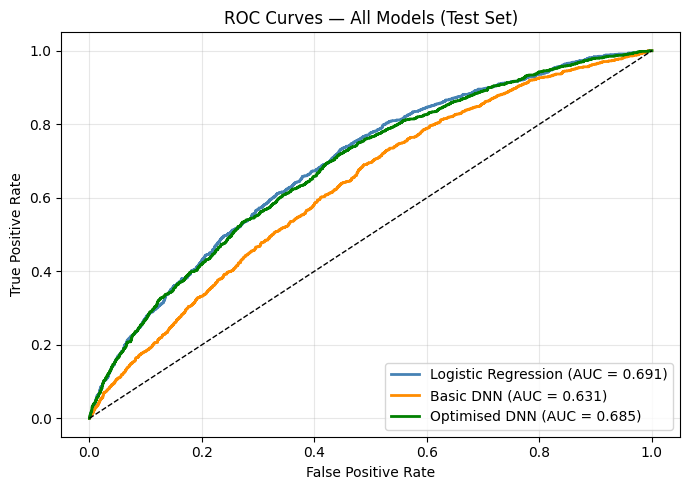

In [ ]:
#ROC Curves
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green']

for (name, res), color in zip(results_overall.items(), colors):
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {res["auc"]:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation by Cluster (Segmentation)

In [ ]:
#Evaluate the best-performing model across the three Q2 clusters

cluster_results = {}
for cluster_id, cluster_name in cluster_names.items():
    mask = (cl_test == cluster_id)
    X_cl = X_test_sc[mask]
    y_cl = y_test[mask]

    if len(X_cl) == 0:
        continue

    cl_rows = []
    for name, model in models.items():
        res = evaluate_on_raw(model, X_cl, y_cl)
        cl_rows.append({
            'Model':    name,
            'Cluster':  cluster_name,
            'N':        len(y_cl),
            'Default%': f'{y_cl.mean():.1%}',
            'Accuracy': f'{res["accuracy"]:.4f}',
            'ROC-AUC':  f'{res["auc"]:.4f}' if not np.isnan(res["auc"]) else 'N/A',
            'Recall':   f'{recall_score(y_cl, res["preds"]):.4f}',
            'Precision':f'{precision_score(y_cl, res["preds"], zero_division=0):.4f}',
        })
    cluster_results[cluster_name] = cl_rows

# Print cluster-level table
all_rows = [row for rows in cluster_results.values() for row in rows]
cluster_df = pd.DataFrame(all_rows)
print('Per-Cluster Model Performance (Test Set):')
print(cluster_df.to_string(index=False))

Per-Cluster Model Performance (Test Set):
              Model       Cluster    N Default% Accuracy ROC-AUC Recall Precision
Logistic Regression High-Leverage 1476    17.9%   0.5833  0.7235 0.7879    0.2712
          Basic DNN High-Leverage 1476    17.9%   0.5291  0.6304 0.6818    0.2276
      Optimised DNN High-Leverage 1476    17.9%   0.6226  0.7108 0.6894    0.2770
Logistic Regression Prior Default  671    11.8%   0.6051  0.6848 0.7468    0.1941
          Basic DNN Prior Default  671    11.8%   0.5082  0.6277 0.6962    0.1524
      Optimised DNN Prior Default  671    11.8%   0.6125  0.6779 0.6582    0.1825
Logistic Regression  Conservative 5079    15.3%   0.6421  0.6813 0.6049    0.2373
          Basic DNN  Conservative 5079    15.3%   0.5600  0.6316 0.6422    0.2032
      Optimised DNN  Conservative 5079    15.3%   0.6493  0.6774 0.5856    0.2377


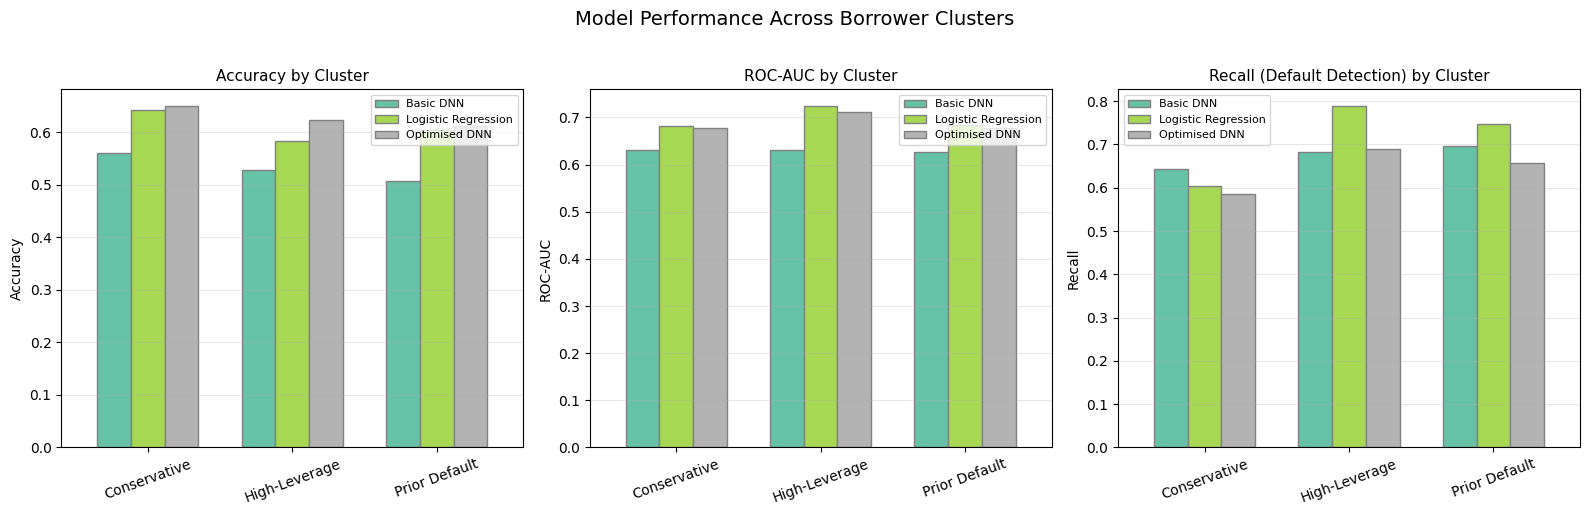

In [ ]:
#Cluster Performance Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

metric_cols = ['Accuracy', 'ROC-AUC', 'Recall']
titles = ['Accuracy by Cluster', 'ROC-AUC by Cluster', 'Recall (Default Detection) by Cluster']

for ax, metric, title in zip(axes, metric_cols, titles):
    plot_data = []
    for cluster_name, rows in cluster_results.items():
        for row in rows:
            val = row[metric]
            if val != 'N/A':
                plot_data.append({'Cluster': cluster_name, 'Model': row['Model'], 'Value': float(val)})

    plot_df = pd.DataFrame(plot_data)
    pivot = plot_df.pivot(index='Cluster', columns='Model', values='Value')
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='gray', width=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Across Borrower Clusters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Default Rate by Cluster
print('Test Set — Cluster Summary:')
for cluster_id, cluster_name in cluster_names.items():
    mask = (cl_test == cluster_id)
    n = mask.sum()
    rate = y_test[mask].mean() if n > 0 else 0
    print(f'  Cluster {cluster_id} ({cluster_name}): n={n}, default rate={rate:.2%}')

Test Set — Cluster Summary:
  Cluster 0 (High-Leverage): n=1476, default rate=17.89%
  Cluster 1 (Prior Default): n=671, default rate=11.77%
  Cluster 2 (Conservative): n=5079, default rate=15.30%


## Confusion Metrices by Cluster

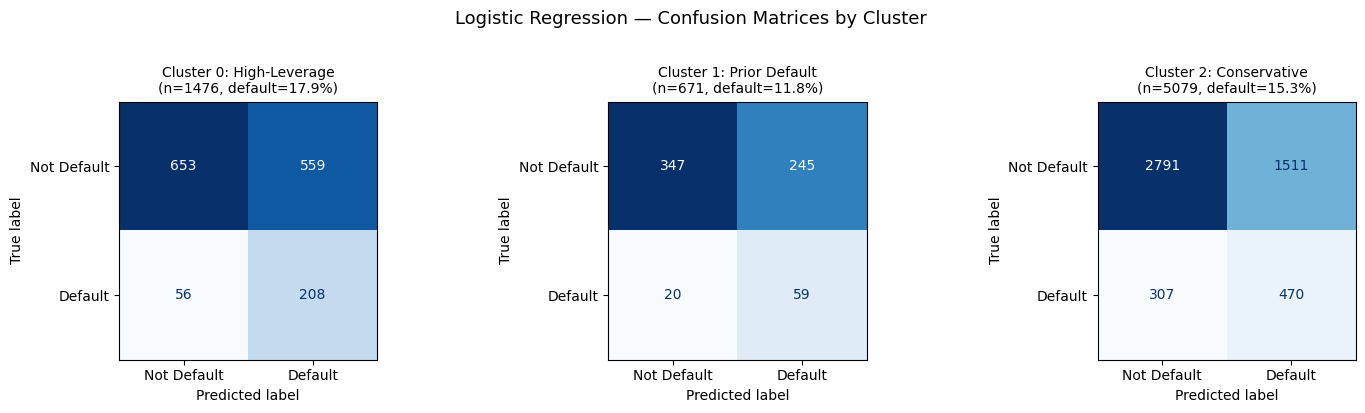

In [ ]:
#Logistic Regression: Cluster Confusion Metrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (cluster_id, cluster_name) in zip(axes, cluster_names.items()):
    mask = (cl_test == cluster_id)
    X_cl = X_test_sc[mask]
    y_cl = y_test[mask]

    if len(X_cl) == 0:
        ax.axis('off')
        continue

    res = evaluate_on_raw(lr_model, X_cl, y_cl)
    cm = confusion_matrix(y_cl, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Default', 'Default']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Cluster {cluster_id}: {cluster_name}\n'
                 f'(n={len(y_cl)}, default={y_cl.mean():.1%})', fontsize=10)

plt.suptitle('Logistic Regression — Confusion Matrices by Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

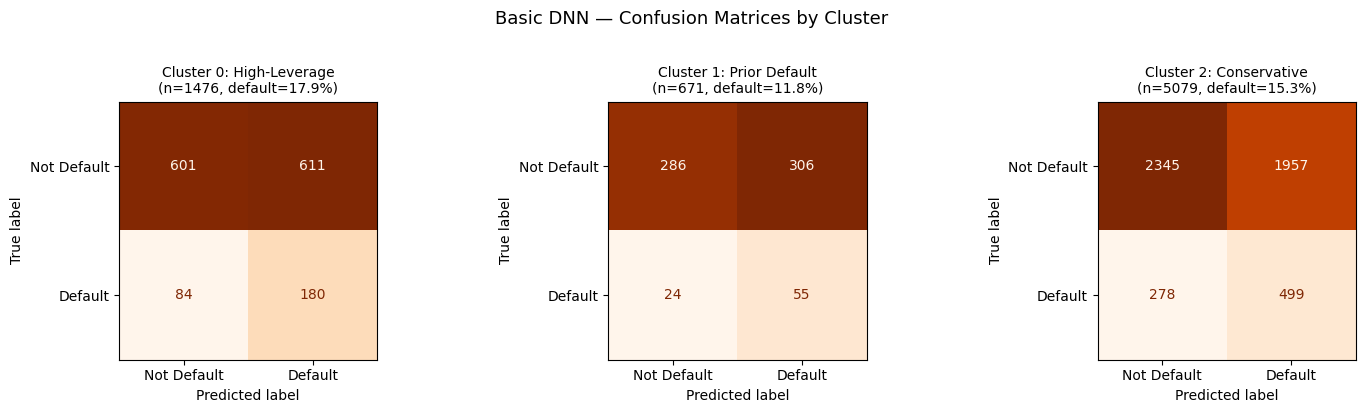

In [ ]:
#Basic DNN: Cluster Confusion Metrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (cluster_id, cluster_name) in zip(axes, cluster_names.items()):
    mask = (cl_test == cluster_id)
    X_cl = X_test_sc[mask]
    y_cl = y_test[mask]

    if len(X_cl) == 0:
        ax.axis('off')
        continue

    res = evaluate_on_raw(dnn_model, X_cl, y_cl)
    cm = confusion_matrix(y_cl, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Default', 'Default']).plot(
        ax=ax, colorbar=False, cmap='Oranges'
    )
    ax.set_title(f'Cluster {cluster_id}: {cluster_name}\n'
                 f'(n={len(y_cl)}, default={y_cl.mean():.1%})', fontsize=10)

plt.suptitle('Basic DNN — Confusion Matrices by Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

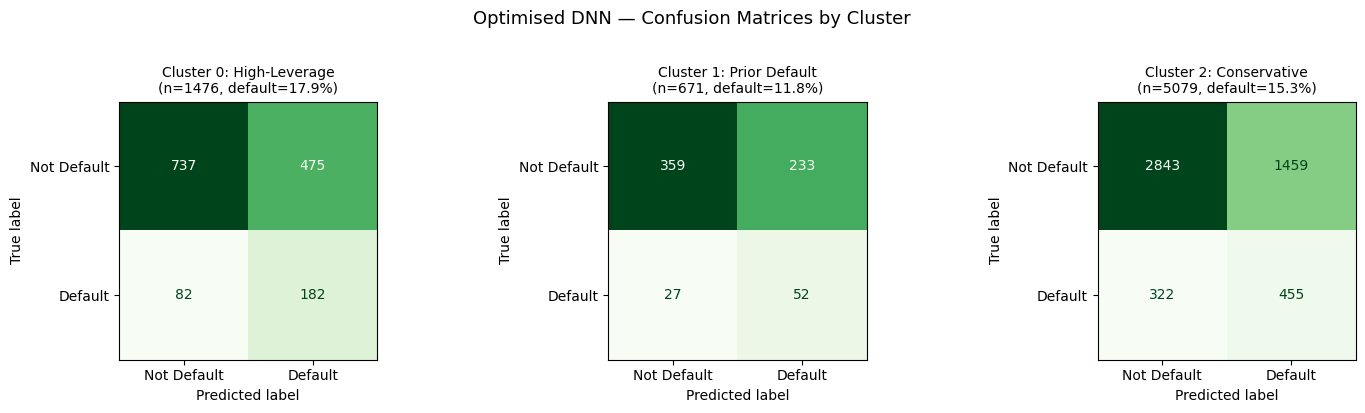

In [ ]:
#Optimised DNN: Cluster Confusion Metrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (cluster_id, cluster_name) in zip(axes, cluster_names.items()):
    mask = (cl_test == cluster_id)
    X_cl = X_test_sc[mask]
    y_cl = y_test[mask]

    if len(X_cl) == 0:
        ax.axis('off')
        continue

    res = evaluate_on_raw(opt_model, X_cl, y_cl)
    cm = confusion_matrix(y_cl, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Default', 'Default']).plot(
        ax=ax, colorbar=False, cmap='Greens'
    )
    ax.set_title(f'Cluster {cluster_id}: {cluster_name}\n'
                 f'(n={len(y_cl)}, default={y_cl.mean():.1%})', fontsize=10)

plt.suptitle('Optimised DNN — Confusion Matrices by Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()